In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import spacy
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from transformers import pipeline

from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge

warnings.filterwarnings("ignore")

2. Datasets Path

In [2]:
DATA_DIR = Path("/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final")

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)

Train directory: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train
Test directory: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test


3. Load CSV files

In [3]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(
    DATA_DIR / "sample_submission.csv"
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

print("\nSample submission columns:")
print(sample_submission.columns.tolist())

Train shape: (769, 2)
Test shape: (216, 2)
Sample submission shape: (204, 2)

Train columns:
['filename', 'label']

Test columns:
['filename', 'label']

Sample submission columns:
['filename', 'label']


4. Verify audio files

In [4]:
train_audio_files = [f for f in TRAIN_DIR.rglob("*")if f.is_file()]

test_audio_files = [ f for f in TEST_DIR.rglob("*")if f.is_file()]

print("Training audio files:", len(train_audio_files))
print("Testing audio files:", len(test_audio_files))

Training audio files: 769
Testing audio files: 216


Check that every CSV filename exists

In [5]:
train_audio_names = {f.name for f in train_audio_files}

test_audio_names = {f.name for f in test_audio_files}

missing_train = set(train_df["filename"]) - train_audio_names
missing_test = set(test_df["filename"]) - test_audio_names

print("Missing training files:", len(missing_train))
print("Missing testing files:", len(missing_test))

Missing training files: 0
Missing testing files: 0


5. Explore target labels

In [6]:
print(train_df["label"].describe())

print("\nLabel distribution:")
print(train_df["label"].value_counts().sort_index())

count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64

Label distribution:
label
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133
Name: count, dtype: int64


Plot

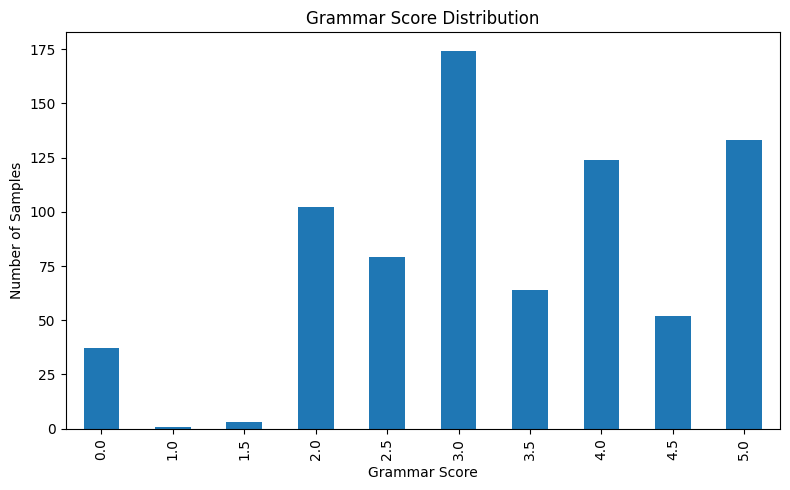

In [7]:
plt.figure(figsize=(8, 5))

train_df["label"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Grammar Score")
plt.ylabel("Number of Samples")
plt.title("Grammar Score Distribution")
plt.tight_layout()
plt.show()

6. Baseline

In [8]:
y = train_df["label"]

baseline_prediction = np.full(
    len(y),
    y.mean()
)

baseline_rmse = np.sqrt(
    mean_squared_error(y, baseline_prediction)
)

print("Mean grammar score:", y.mean())
print("Baseline RMSE:", baseline_rmse)

Mean grammar score: 3.3133940182054618
Baseline RMSE: 1.2381936808002134


7. Audio feature extraction

In [9]:
def extract_audio_features(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=None
    )

    duration = len(audio) / sr

    rms = np.mean(
        librosa.feature.rms(y=audio)
    )

    zcr = np.mean(
        librosa.feature.zero_crossing_rate(audio)
    )

    mfcc = np.mean(
        librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=13
        ),
        axis=1
    )

    features = {
        "duration": duration,
        "rms": rms,
        "zcr": zcr
    }

    for i, value in enumerate(mfcc):
        features[f"mfcc_{i+1}"] = value

    return features

Extract training features:

In [10]:
audio_features = []

for _, row in tqdm(
    train_df.iterrows(),
    total=len(train_df)
):

    file_path = TRAIN_DIR / row["filename"]

    features = extract_audio_features(
        file_path
    )

    features["filename"] = row["filename"]
    features["label"] = row["label"]

    audio_features.append(features)

train_features = pd.DataFrame(
    audio_features
)

print(train_features.shape)
train_features.head()

  0%|          | 0/769 [00:00<?, ?it/s]

(769, 18)


,duration,rms,zcr,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,filename,label
0,60.508375,0.031786,0.084768,-403.835876,103.576317,-14.213526,16.673613,7.048553,-4.999640,5.885731,-9.268932,-8.681059,-6.111349,-11.947042,-8.226156,-6.238203,audio_192.wav,3.0
1,60.074688,0.068651,0.142977,-287.111023,72.087601,5.334724,24.854349,-13.109428,0.168592,-15.632076,-20.825958,-6.671187,-8.470199,-9.261224,-9.040758,4.751498,audio_436.wav,3.0
2,60.074688,0.054421,0.146870,-324.808228,97.828194,18.635796,5.857048,2.258683,-16.368387,-24.105776,-6.395788,-8.089577,-8.570185,3.306297,-3.113312,-0.866495,audio_447.wav,3.5
3,45.060000,0.013778,0.059477,-489.320648,111.792908,0.751581,33.133244,8.309437,8.676815,-11.291532,-20.012394,-15.253530,-21.515909,-12.347360,-9.993058,-17.710951,audio_126.wav,2.0
4,45.300000,0.009330,0.169988,-483.866028,51.975899,-21.642136,31.146597,-11.265674,-14.069729,-13.595560,-16.988165,-9.642052,-18.795963,-8.590364,3.873606,-17.764481,audio_61.wav,2.0


8. Load Whisper

In [11]:
asr_pipeline = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-tiny",
    device=-1
)

print("Whisper loaded successfully")

config.json:   0%|          | 0.00/1.98k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  151MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.75k [00:00<?, ?B/s]

...

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

Whisper loaded successfully


9. Transcription function

In [12]:
def transcribe_audio(file_path):

    result = asr_pipeline(
        str(file_path),
        return_timestamps=True,
        generate_kwargs={
            "language": "english"
        }
    )

    return result["text"].strip()

Test:

In [13]:
sample_file = TRAIN_DIR / train_df.iloc[0]["filename"]

sample_text = transcribe_audio(
    sample_file
)

print(sample_text)

[transformers] Passing `generation_config` together with generation-related arguments=({'begin_suppress_tokens', 'suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Well, the play plant is very, very beautiful and fun. There are play things like the middle and the swing, the swing usually enjoy the swing. It has to be like, it's more like a game of play. Once it's finished and the other thing is now we'll have to finish and move around which is fine, honey, and then, most of the things left for us. and perhaps why others use this thing, some of the key breaks into some classes. And most times, he had the sound of swimming through during last year.


10. Transcribe all training audio

In [14]:
transcripts = []

for _, row in tqdm(
    train_df.iterrows(),
    total=len(train_df)
):

    file_path = TRAIN_DIR / row["filename"]

    text = transcribe_audio(
        file_path
    )

    transcripts.append({
        "filename": row["filename"],
        "transcript": text
    })

transcript_df = pd.DataFrame(
    transcripts
)

print(transcript_df.shape)
transcript_df.head()

  0%|          | 0/769 [00:00<?, ?it/s]

[transformers] Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.
[transformers] Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.
[transformers] Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.
[transformers] Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.
[transformers] Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.
[transformers] 

(769, 2)


,filename,transcript
0,audio_192.wav,"Well, the play plant is very, very beautiful a..."
1,audio_436.wav,"The scene of a school playground, our playgrou..."
2,audio_447.wav,My favorite place to reject is the beach. I lo...
3,audio_126.wav,"Once upon a time we went on a tube, went on a ..."
4,audio_61.wav,"Well, when I was a child, I remember, I went t..."


11. Basic text features

In [15]:
def extract_text_features(text):

    text = str(text).strip()

    words = re.findall(
        r"\b[a-zA-Z]+\b",
        text.lower()
    )

    sentences = re.split(
        r"[.!?]+",
        text
    )

    sentences = [
        s.strip()
        for s in sentences
        if s.strip()
    ]

    word_count = len(words)
    sentence_count = len(sentences)
    unique_words = len(set(words))

    avg_sentence_length = (
        word_count / sentence_count
        if sentence_count > 0
        else 0
    )

    unique_word_ratio = (
        unique_words / word_count
        if word_count > 0
        else 0
    )

    repeated_word_ratio = (
        1 - unique_word_ratio
        if word_count > 0
        else 0
    )

    avg_word_length = (
        np.mean([
            len(word)
            for word in words
        ])
        if words
        else 0
    )

    return {
        "word_count": word_count,
        "sentence_count": sentence_count,
        "avg_sentence_length": avg_sentence_length,
        "unique_word_ratio": unique_word_ratio,
        "repeated_word_ratio": repeated_word_ratio,
        "avg_word_length": avg_word_length
    }

test

In [16]:
text_features = []

for _, row in transcript_df.iterrows():

    features = extract_text_features(
        row["transcript"]
    )

    features["filename"] = row["filename"]

    text_features.append(features)

text_features_df = pd.DataFrame(
    text_features
)

print(text_features_df.shape)

(769, 7)


12. spaCy grammar features

In [17]:
nlp = spacy.load(
    "en_core_web_sm"
)

Function

In [18]:
def extract_spacy_features(text):

    doc = nlp(str(text))

    tokens = [
        token
        for token in doc
        if not token.is_space
        and not token.is_punct
    ]

    word_count = len(tokens)

    if word_count == 0:

        return {
            "noun_ratio": 0,
            "verb_ratio": 0,
            "adjective_ratio": 0,
            "adverb_ratio": 0,
            "pronoun_ratio": 0,
            "determiner_ratio": 0,
            "preposition_ratio": 0,
            "auxiliary_ratio": 0,
            "conjunction_ratio": 0,
            "past_tense_ratio": 0,
            "present_tense_ratio": 0,
            "future_tense_ratio": 0,
            "dependency_depth": 0
        }

    pos_counts = {}

    for token in tokens:

        pos_counts[token.pos_] = (
            pos_counts.get(token.pos_, 0) + 1
        )

    def ratio(pos):

        return (
            pos_counts.get(pos, 0)
            / word_count
        )

    past = sum(
        1
        for token in tokens
        if token.tag_ in ["VBD", "VBN"]
    )

    present = sum(
        1
        for token in tokens
        if token.tag_ in ["VBP", "VBZ", "VBG"]
    )

    future = sum(
        1
        for token in tokens
        if token.text.lower()
        in ["will", "shall"]
    )

    depths = []

    for token in tokens:

        depth = 0
        current = token

        while current.head != current:

            depth += 1
            current = current.head

        depths.append(depth)

    return {
        "noun_ratio": ratio("NOUN"),
        "verb_ratio": ratio("VERB"),
        "adjective_ratio": ratio("ADJ"),
        "adverb_ratio": ratio("ADV"),
        "pronoun_ratio": ratio("PRON"),
        "determiner_ratio": ratio("DET"),
        "preposition_ratio": ratio("ADP"),
        "auxiliary_ratio": ratio("AUX"),
        "conjunction_ratio": (
            ratio("CCONJ") +
            ratio("SCONJ")
        ),
        "past_tense_ratio": past / word_count,
        "present_tense_ratio": present / word_count,
        "future_tense_ratio": future / word_count,
        "dependency_depth": np.mean(depths)
    }

Apply

In [19]:
spacy_features = []

for _, row in tqdm(
    transcript_df.iterrows(),
    total=len(transcript_df)
):

    features = extract_spacy_features(
        row["transcript"]
    )

    features["filename"] = row["filename"]

    spacy_features.append(features)

spacy_features_df = pd.DataFrame(
    spacy_features
)

print(spacy_features_df.shape)

  0%|          | 0/769 [00:00<?, ?it/s]

(769, 14)


13. Merge everything

In [20]:
combined_df = (
    train_features
    .merge(
        text_features_df,
        on="filename",
        how="inner"
    )
    .merge(
        spacy_features_df,
        on="filename",
        how="inner"
    )
)

print("Final dataset shape:", combined_df.shape)

Final dataset shape: (769, 37)


14. Prepare X and y

In [21]:
X = combined_df.drop(
    columns=["filename", "label"]
)

y = combined_df["label"]

print("Samples:", X.shape[0])
print("Features:", X.shape[1])
        

Samples: 769
Features: 35


15. 5-Fold Cross Validation

In [22]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_predictions = np.zeros(
    len(X)
)

fold_rmses = []

Train

In [23]:
for fold, (train_idx, valid_idx) in enumerate(
    kf.split(X),
    1
):

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_valid
    )

    oof_predictions[valid_idx] = predictions

    fold_rmse = np.sqrt(
        mean_squared_error(
            y_valid,
            predictions
        )
    )

    fold_rmses.append(
        fold_rmse
    )

    print(
        f"Fold {fold}: "
        f"RMSE = {fold_rmse:.4f}"
    )

Fold 1: RMSE = 0.7542
Fold 2: RMSE = 0.8218
Fold 3: RMSE = 0.8484
Fold 4: RMSE = 0.7433
Fold 5: RMSE = 0.8224


Overall OOF RMSE

In [24]:
oof_rmse = np.sqrt(
    mean_squared_error(
        y,
        oof_predictions
    )
)

print("\nFold RMSEs:")
print(fold_rmses)

print(
    "\nMean CV RMSE:",
    np.mean(fold_rmses)
)

print(
    "OOF RMSE:",
    oof_rmse
)



Fold RMSEs:
[np.float64(0.7542082395085381), np.float64(0.8217639317930422), np.float64(0.8484348122228546), np.float64(0.7432693904126462), np.float64(0.822391554282283)]

Mean CV RMSE: 0.7980135856438727
OOF RMSE: 0.7990618596280323


16. Training RMSE

In [25]:
final_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X,
    y
)

train_predictions = final_model.predict(
    X
)

training_rmse = np.sqrt(
    mean_squared_error(
        y,
        train_predictions
    )
)

print(
    "Training RMSE:",
    training_rmse
)


Training RMSE: 0.29660671238057884


17. Feature importance

In [26]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": final_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df.head(15)

,feature,importance
2,zcr,0.196960
4,mfcc_2,0.132216
3,mfcc_1,0.129021
16,word_count,0.080936
19,unique_word_ratio,0.034054
20,repeated_word_ratio,0.032177
1,rms,0.023558
5,mfcc_3,0.021960
11,mfcc_9,0.020881
32,present_tense_ratio,0.019232


plot

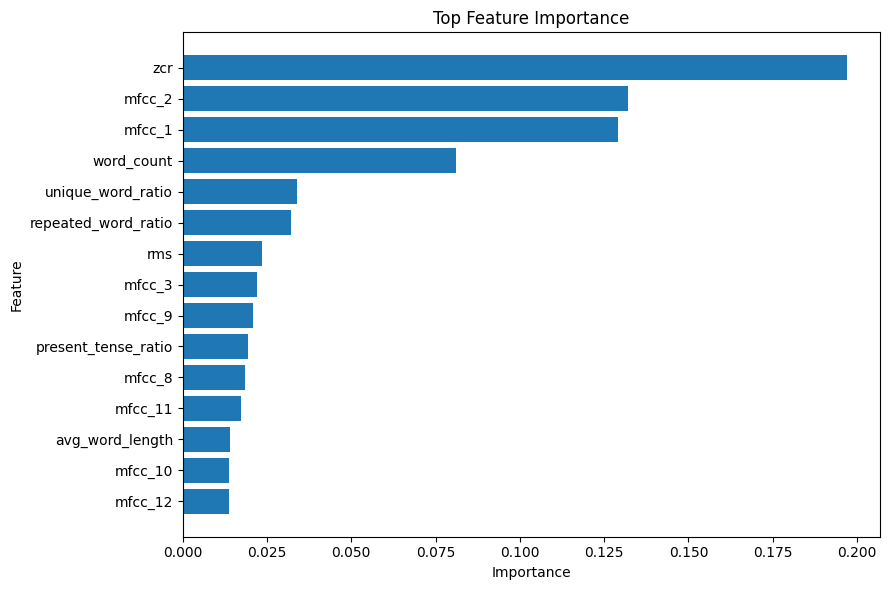

In [27]:
top_features = importance_df.head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importance")

plt.tight_layout()
plt.show()

18. Process test audio

In [28]:
test_audio_features = []

for _, row in tqdm(
    test_df.iterrows(),
    total=len(test_df)
):

    file_path = TEST_DIR / row["filename"]

    features = extract_audio_features(
        file_path
    )

    features["filename"] = row["filename"]

    test_audio_features.append(
        features
    )

test_audio_features_df = pd.DataFrame(
    test_audio_features
)

print(
    test_audio_features_df.shape
)

  0%|          | 0/216 [00:00<?, ?it/s]

(216, 17)


19. Transcribe test audio

In [29]:
test_transcripts = []

for _, row in tqdm(
    test_df.iterrows(),
    total=len(test_df)
):

    file_path = TEST_DIR / row["filename"]

    text = transcribe_audio(
        file_path
    )

    test_transcripts.append({
        "filename": row["filename"],
        "transcript": text
    })

test_transcript_df = pd.DataFrame(
    test_transcripts
)

print(
    test_transcript_df.shape
)

  0%|          | 0/216 [00:00<?, ?it/s]

[transformers] Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.
[transformers] Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.
[transformers] Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.
[transformers] Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.
[transformers] Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.
[transformers] 

(216, 2)


20. Test text features

In [30]:
test_text_features = []

for _, row in test_transcript_df.iterrows():

    features = extract_text_features(
        row["transcript"]
    )

    features["filename"] = row["filename"]

    test_text_features.append(
        features
    )

test_text_features_df = pd.DataFrame(
    test_text_features
)

21. Test spaCy features

In [31]:
test_spacy_features = []

for _, row in tqdm(
    test_transcript_df.iterrows(),
    total=len(test_transcript_df)
):

    features = extract_spacy_features(
        row["transcript"]
    )

    features["filename"] = row["filename"]

    test_spacy_features.append(
        features
    )

test_spacy_features_df = pd.DataFrame(
    test_spacy_features
)

  0%|          | 0/216 [00:00<?, ?it/s]

22. Merge test features

In [32]:
test_combined_df = (
    test_audio_features_df
    .merge(
        test_text_features_df,
        on="filename",
        how="inner"
    )
    .merge(
        test_spacy_features_df,
        on="filename",
        how="inner"
    )
)

print(
    "Test feature shape:",
    test_combined_df.shape
)

Test feature shape: (216, 36)


23. Ensure test columns match training

In [33]:
X_test = test_combined_df[
    X.columns
]

print(
    "Training features:",
    X.shape[1]
)

print(
    "Test features:",
    X_test.shape[1]
)

Training features: 35
Test features: 35


24. Train final model

In [34]:
final_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X,
    y
)

RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=42)

25. Predict test scores

In [35]:
test_predictions = final_model.predict(
    X_test
)

test_predictions = np.clip(
    test_predictions,
    1,
    5
)

print(test_predictions[:10])
print("Number of predictions:", len(test_predictions))

[2.809 3.714 3.777 3.071 2.822 3.139 3.086 3.096 3.129 2.844]
Number of predictions: 216


26. Create submission

In [36]:
print(sample_submission.head())
print(sample_submission.columns.tolist())
print(sample_submission.shape)

         filename  label
0   audio_804.wav     -1
1  audio_1028.wav     -1
2   audio_865.wav     -1
3   audio_774.wav     -1
4  audio_1138.wav     -1
['filename', 'label']
(204, 2)


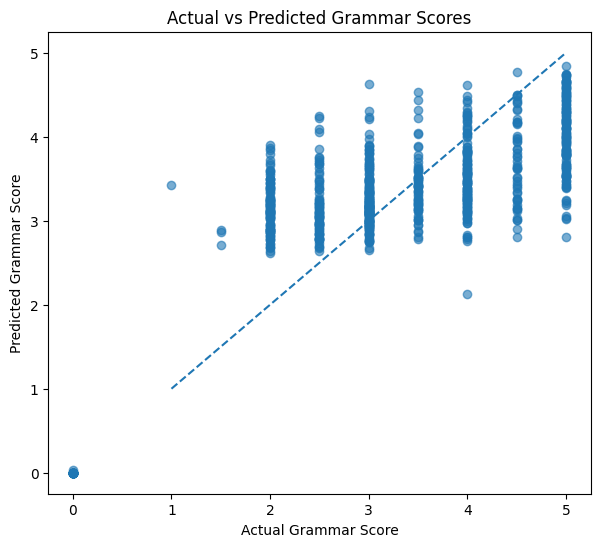

In [37]:
plt.figure(figsize=(7, 6))

plt.scatter(y, oof_predictions, alpha=0.6)

plt.xlabel("Actual Grammar Score")
plt.ylabel("Predicted Grammar Score")
plt.title("Actual vs Predicted Grammar Scores")

plt.plot([1, 5], [1, 5], linestyle="--")

plt.show()

In [38]:
from scipy.stats import pearsonr

pearson_corr, p_value = pearsonr(y, oof_predictions)

print("Pearson Correlation:", pearson_corr)
print("RMSE:", np.sqrt(mean_squared_error(y, oof_predictions)))

Pearson Correlation: 0.7655781763964399
RMSE: 0.7990618596280323
